In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#Exercício Pratico 1

## 1. Comparação entre DTFT e DFT

Vamos começar definindo o sinal `x[n]` e implementando as funções para calcular a DTFT e a DFT.

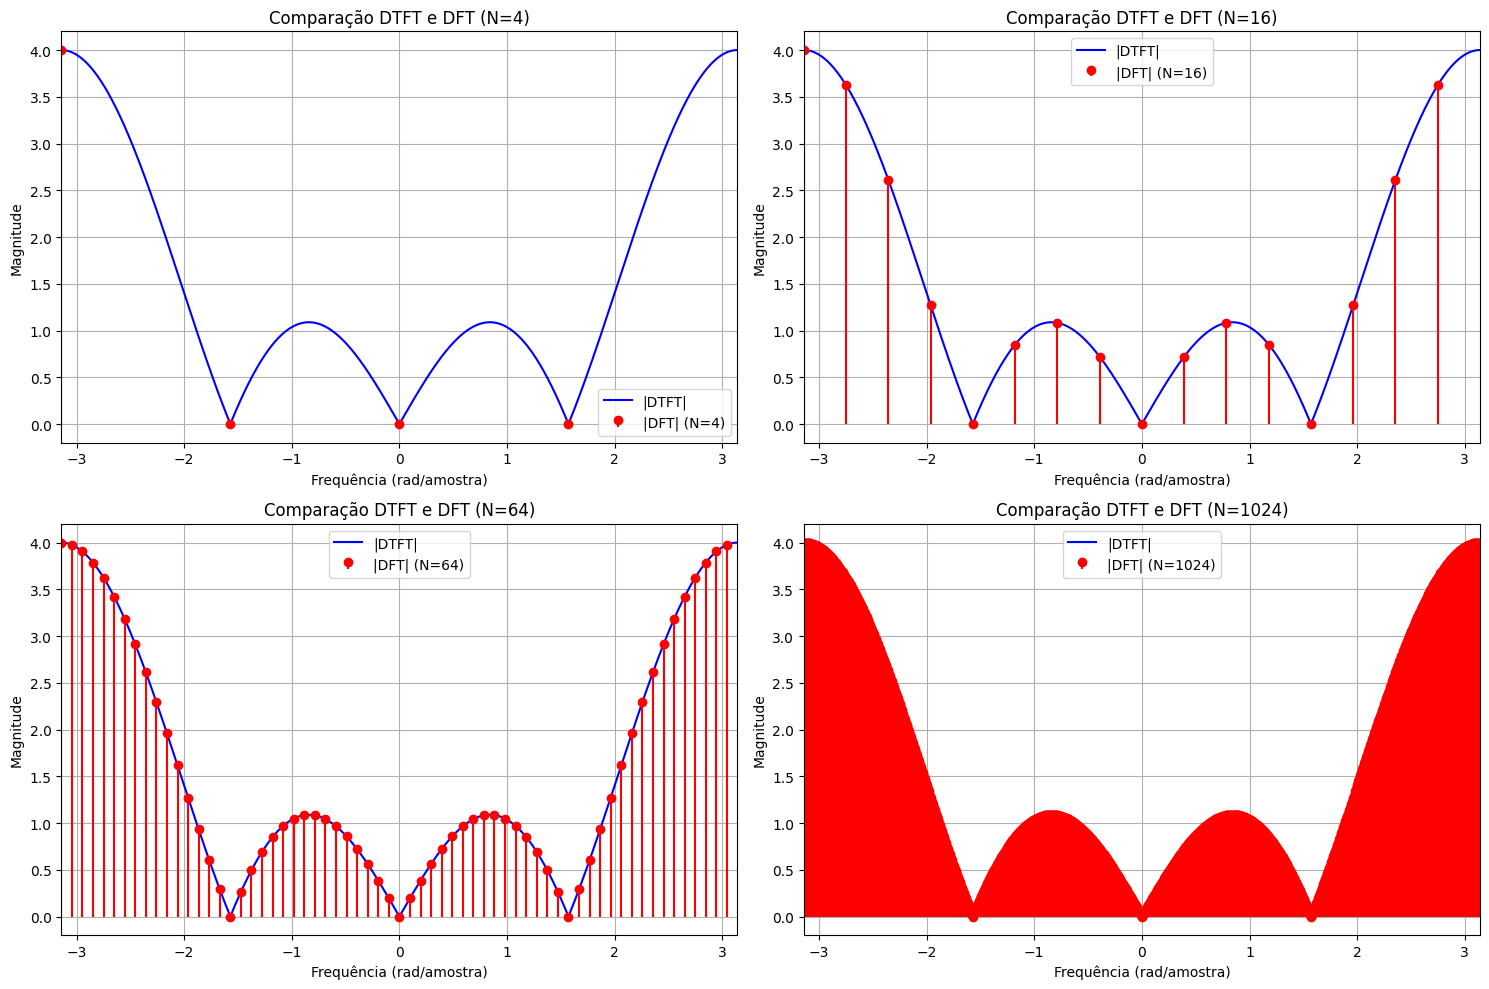

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Definir o sinal x[n] = δ[n] − δ[n − 1] + δ[n − 2] − δ[n − 3]
x_n = np.array([1, -1, 1, -1])

# Função para calcular a DTFT
def calculate_dtft(x, omega_points=1000):
    N = len(x)
    omega = np.linspace(-np.pi, np.pi, omega_points)
    dtft = np.array([np.sum(x * np.exp(-1j * w * np.arange(N))) for w in omega])
    return omega, dtft

# Função para calcular a DFT
def calculate_dft(x, N_dft):
    # Pad x with zeros if N_dft > len(x)
    x_padded = np.pad(x, (0, N_dft - len(x)), 'constant') if N_dft > len(x) else x[:N_dft]
    dft = np.fft.fft(x_padded, N_dft)
    # Frequencies for DFT are 2*pi*k/N_dft for k = 0, ..., N_dft-1
    # We map them to [-pi, pi] for comparison with DTFT
    omega_dft = 2 * np.pi * np.fft.fftfreq(N_dft, d=1)
    # Sort frequencies to plot correctly (fft.fftfreq gives values in [0, pi] and then [-pi, 0))
    sorted_indices = np.argsort(omega_dft)
    return omega_dft[sorted_indices], dft[sorted_indices]


# Calcular DTFT
omega_dtft, dtft_spectrum = calculate_dtft(x_n)

# Valores de N para a DFT
Ns = [4, 16, 64, 1024]

plt.figure(figsize=(15, 10))

for i, N in enumerate(Ns):
    omega_dft, dft_spectrum = calculate_dft(x_n, N)

    plt.subplot(2, 2, i + 1)
    plt.plot(omega_dtft, np.abs(dtft_spectrum), label='|DTFT|', color='blue')
    plt.stem(omega_dft, np.abs(dft_spectrum), linefmt='red', markerfmt='ro', basefmt=' ', label=f'|DFT| (N={N})')
    plt.title(f'Comparação DTFT e DFT (N={N})')
    plt.xlabel('Frequência (rad/amostra)')
    plt.ylabel('Magnitude')
    plt.grid(True)
    plt.legend()
    plt.xlim([-np.pi, np.pi]) # Ensure same frequency range

plt.tight_layout()
plt.show()

### Comentários sobre os resultados da Parte 1:

Nos gráficos acima, a linha azul representa a magnitude da Transformada de Fourier de Tempo Discreto (DTFT), que é uma função contínua no domínio da frequência. Os pontos vermelhos representam a magnitude da Transformada Discreta de Fourier (DFT) para diferentes tamanhos de `N`.

Podemos observar que:

*   **N = 4:** Neste caso, o número de pontos da DFT (`N=4`) é exatamente igual ao comprimento do sinal `x[n]`. A DFT amostra a DTFT em 4 pontos de frequência discretos (0, π/2, π, 3π/2 ou 0, π/2, -π, -π/2, dependendo do mapeamento para [-π, π]). Nesses pontos, a magnitude da DFT coincide perfeitamente com a magnitude da DTFT.

*   **N = 16, 64, 1024:** À medida que `N` (o número de pontos da DFT) aumenta, a DFT amostra a DTFT em um número maior de pontos discretos e mais espaçados no domínio da frequência. Isso faz com que os pontos da DFT se aproximem cada vez mais da curva contínua da DTFT. Essencialmente, a DFT se torna uma amostragem mais fina da DTFT.

Em resumo, a DFT é uma versão amostrada da DTFT. À medida que o número de pontos `N` da DFT aumenta, a resolução da amostragem no domínio da frequência melhora, e a DFT se aproxima da representação contínua da DTFT. Para um sinal de comprimento finito `L`, se `N >= L`, a DFT de `x[n]` com zero-padding fornecerá `N` amostras da DTFT do sinal original.

## 2. Impacto do Tamanho da DFT na Resolução

Agora vamos analisar como o tamanho da DFT e o zero-padding afetam a resolução espectral para o sinal `x(t) = sin(2πt) + sin(2, 02πt)` amostrado com `fs = 10 Hz`.

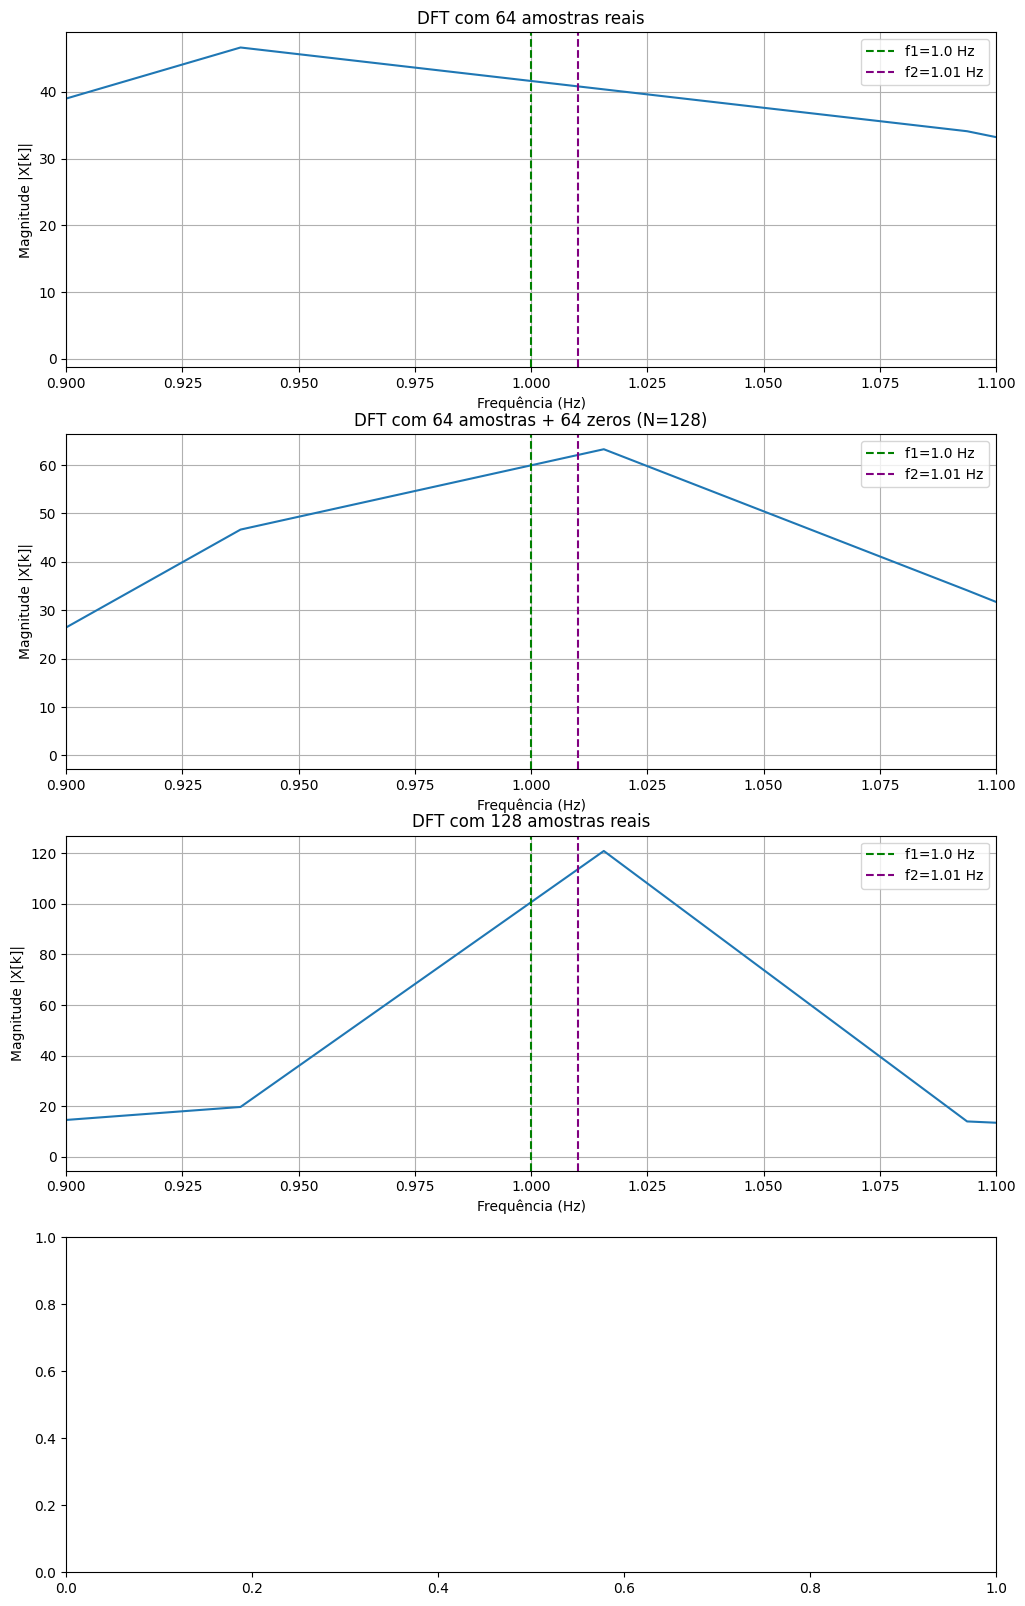

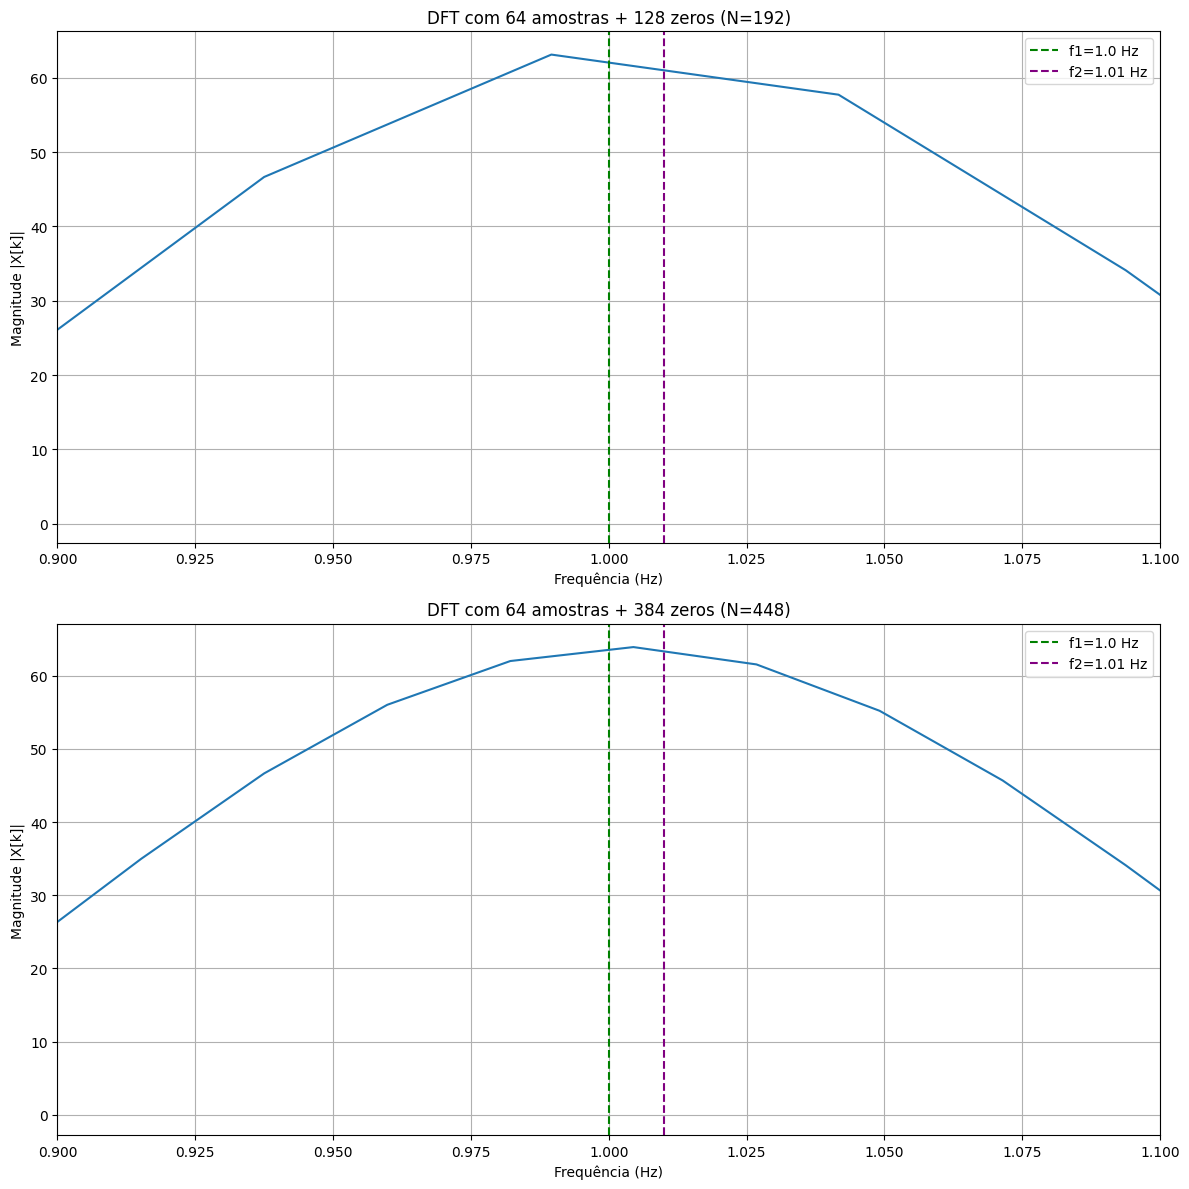

In [2]:
# Parâmetros do sinal
fs = 10  # Frequência de amostragem em Hz
T = 1/fs # Período de amostragem

# Frequências dos componentes do sinal contínuo
f1 = 1.0 # Hz (2πf1t -> 2πt => f1=1)
f2 = 1.01 # Hz (2πf2t -> 2.02πt => f2=1.01)

def generate_signal(num_samples):
    n = np.arange(num_samples) # Índices das amostras
    t = n * T # Tempo de amostragem
    x_t = np.sin(2 * np.pi * f1 * t) + np.sin(2 * np.pi * f2 * t)
    return x_t


# Função auxiliar para plotar o espectro da DFT
def plot_dft_spectrum(signal, N_dft, title, original_num_samples, ax):
    # Zero-padding se N_dft for maior que o comprimento do sinal
    padded_signal = np.pad(signal, (0, N_dft - len(signal)), 'constant') if N_dft > len(signal) else signal

    dft_spectrum = np.fft.fft(padded_signal, N_dft)
    magnitudes = np.abs(dft_spectrum)

    # Calcular frequências em Hz
    # fftfreq retorna frequências normalizadas de -0.5 a 0.5
    frequencies = np.fft.fftfreq(N_dft, d=T)

    # Plotar apenas as frequências positivas para sinais reais
    positive_freq_indices = np.where(frequencies >= 0)
    positive_frequencies = frequencies[positive_freq_indices]
    positive_magnitudes = magnitudes[positive_freq_indices]

    ax.plot(positive_frequencies, positive_magnitudes)
    ax.set_title(title)
    ax.set_xlabel('Frequência (Hz)')
    ax.set_ylabel('Magnitude |X[k]|')
    ax.grid(True)
    ax.set_xlim([0.9, 1.1]) # Focar nas frequências de interesse
    ax.axvline(f1, color='green', linestyle='--', label=f'f1={f1} Hz')
    ax.axvline(f2, color='purple', linestyle='--', label=f'f2={f2} Hz')
    ax.legend()


fig, axs = plt.subplots(4, 1, figsize=(12, 20))

# --- Caso 1: 64 amostras reais ---
num_samples_64 = 64
x_n_64 = generate_signal(num_samples_64)
plot_dft_spectrum(x_n_64, num_samples_64, f'DFT com {num_samples_64} amostras reais', num_samples_64, axs[0])

# --- Caso 2: 64 amostras reais + 64 zeros (N_dft = 128) ---
N_dft_128_zp = 128 # 64 amostras originais + 64 zeros
plot_dft_spectrum(x_n_64, N_dft_128_zp, f'DFT com {num_samples_64} amostras + {N_dft_128_zp-num_samples_64} zeros (N={N_dft_128_zp})', num_samples_64, axs[1])

# --- Caso 3: 128 amostras reais ---
num_samples_128 = 128
x_n_128 = generate_signal(num_samples_128)
plot_dft_spectrum(x_n_128, num_samples_128, f'DFT com {num_samples_128} amostras reais', num_samples_128, axs[2])

# --- Caso 4: 64 amostras reais + 128 zeros (N_dft = 192) e 64 amostras reais + 384 zeros (N_dft = 448) ---
# Plotando as duas na mesma subplot para comparação direta ou em subplots separadas,
# vamos fazer em separadas para clareza como nos outros casos, adicionando mais subplots.

# 64 amostras + 128 zeros (N_dft = 192)
N_dft_192_zp = 192
fig2, axs2 = plt.subplots(2, 1, figsize=(12, 12))
plot_dft_spectrum(x_n_64, N_dft_192_zp, f'DFT com {num_samples_64} amostras + {N_dft_192_zp-num_samples_64} zeros (N={N_dft_192_zp})', num_samples_64, axs2[0])

# 64 amostras + 384 zeros (N_dft = 448)
N_dft_448_zp = 448
plot_dft_spectrum(x_n_64, N_dft_448_zp, f'DFT com {num_samples_64} amostras + {N_dft_448_zp-num_samples_64} zeros (N={N_dft_448_zp})', num_samples_64, axs2[1])

plt.tight_layout()
plt.show()

### Comentários sobre os resultados da Parte 2:

Vamos analisar os gráficos gerados para o sinal `x(t) = sin(2πt) + sin(2,02πt)` amostrado a `fs = 10 Hz`:

1.  **DFT com 64 amostras reais (N=64):**
    *   Observamos um único pico largo na região de 1 Hz. As duas frequências constituintes (1 Hz e 1.01 Hz) **não são distinguíveis**. Isso ocorre porque a largura do lóbulo principal da função de janela retangular (implícita pela amostragem finita) é muito grande em relação à diferença entre as frequências. A resolução espectral da DFT é inversamente proporcional ao número de amostras reais do sinal. Com apenas 64 amostras, a resolução é insuficiente para separar componentes de frequência tão próximas.

2.  **DFT com 64 amostras reais + 64 zeros (N=128):**
    *   Ao adicionar zero-padding, observamos que o pico se torna mais estreito e um pouco mais definido, mas as duas frequências ainda **não são claramente separadas**. O zero-padding aumenta o número de pontos de amostragem da DTFT (interpolação no domínio da frequência), o que nos dá uma visualização mais detalhada do espectro, mas não melhora a *resolução inerente* da DFT, que é determinada pelo tempo total de observação do sinal (o número de amostras reais). O zero-padding apenas 'suaviza' o espectro, tornando a forma do pico mais visível, mas não adiciona nova informação sobre as frequências que não foi capturada nas 64 amostras originais.

3.  **DFT com 128 amostras reais (N=128):**
    *   Neste caso, as duas frequências (1 Hz e 1.01 Hz) **tornam-se claramente distinguíveis** como dois picos distintos. Isso acontece porque aumentamos o número real de amostras do sinal de 64 para 128. Ao dobrar o número de amostras reais, dobramos o tempo de observação (`T_observacao = N_amostras / fs`). O aumento do tempo de observação resulta em uma maior resolução espectral, permitindo que a DFT separe componentes de frequência mais próximas. A resolução mínima de frequência é aproximadamente `fs / N_amostras_reais`.

4.  **Efeito de novos aumentos no tamanho da DFT por meio de zero-padding (N=192 e N=448, com 64 amostras reais):**
    *   Nos gráficos de N=192 e N=448 (com as mesmas 64 amostras reais do sinal original e zero-padding adicional), continuamos a ver o efeito de 'suavização' do espectro. Os picos se tornam cada vez mais bem definidos visualmente, mas não conseguimos separar as duas frequências de 1 Hz e 1.01 Hz. A forma do lóbulo principal do espectro da janela de 64 amostras é apenas melhor delineada por mais pontos. Independentemente de quão grande seja o `N` da DFT via zero-padding, se o número de amostras **reais** do sinal não mudar, a capacidade de distinguir frequências muito próximas não será melhorada.

### Conclusão:

*   **Resolução Espectral:** A capacidade de distinguir duas componentes de frequência próximas (resolução espectral) é determinada pelo **número de amostras reais** do sinal e, consequentemente, pelo tempo total de observação. Um maior número de amostras reais leva a uma maior resolução.

*   **Zero-padding:** O zero-padding aumenta o número de pontos da DFT, o que significa que estamos calculando mais amostras da DTFT do sinal. Isso interpola o espectro, tornando-o visualmente mais suave e detalhado. Embora possa ajudar a identificar a localização precisa de um pico existente, ele **não melhora a resolução espectral** do sinal. Ou seja, ele não nos permite distinguir frequências que já não eram distinguíveis com a DFT de menor `N` (com base no número de amostras reais).

*   **Limitações:** O zero-padding é útil para obter uma representação mais densa e suavizada do espectro, o que pode ser benéfico para a visualização ou para encontrar a frequência exata de um pico já resolvido. No entanto, ele não pode compensar a falta de informação contida no sinal original devido a um tempo de observação curto. Para melhorar genuinamente a capacidade de separar frequências próximas, é necessário amostrar o sinal por um período de tempo mais longo, ou seja, aumentar o número de amostras reais.

## 3. Compressão de Sinais 1-D (Áudio) com DFT e DCT

Nesta parte, vamos explorar a compressão de um sinal de áudio (`handel.wav`) usando a DFT e a Transformada de Cossenos Discreta (DCT) para diferentes fatores de compressão de energia.

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import IPython.display as ipd
from scipy.io import wavfile
from scipy.fft import fft, fftfreq
from google.colab import files

print("Please upload the handel.wav file:")
uploaded = files.upload()

filename = list(uploaded.keys())[0]
print(f"File uploaded: {filename}")

Please upload the handel.wav file:


Saving handel.wav to handel (1).wav
File uploaded: handel (1).wav


Frequência de amostragem: 8192 Hz
Duração do sinal: 8.92 segundos

--- Compressão com DFT ---
Fator de compressão (energia): 99.5% -> Coeficientes DFT retidos: 3/73113 (0.00%) | MSE: 5.9839e-02
Fator de compressão (energia): 99.0% -> Coeficientes DFT retidos: 5/73113 (0.01%) | MSE: 5.9546e-02
Fator de compressão (energia): 90.0% -> Coeficientes DFT retidos: 63/73113 (0.09%) | MSE: 5.4140e-02
Fator de compressão (energia): 75.0% -> Coeficientes DFT retidos: 271/73113 (0.37%) | MSE: 4.5112e-02
Fator de compressão (energia): 50.0% -> Coeficientes DFT retidos: 1171/73113 (1.60%) | MSE: 3.0065e-02

--- Compressão com DCT ---
Fator de compressão (energia): 99.5% -> Coeficientes DCT retidos: 1/73113 (0.00%) | MSE: 5.9759e-02
Fator de compressão (energia): 99.0% -> Coeficientes DCT retidos: 2/73113 (0.00%) | MSE: 5.9448e-02
Fator de compressão (energia): 90.0% -> Coeficientes DCT retidos: 39/73113 (0.05%) | MSE: 5.4090e-02
Fator de compressão (energia): 75.0% -> Coeficientes DCT retidos: 185/7

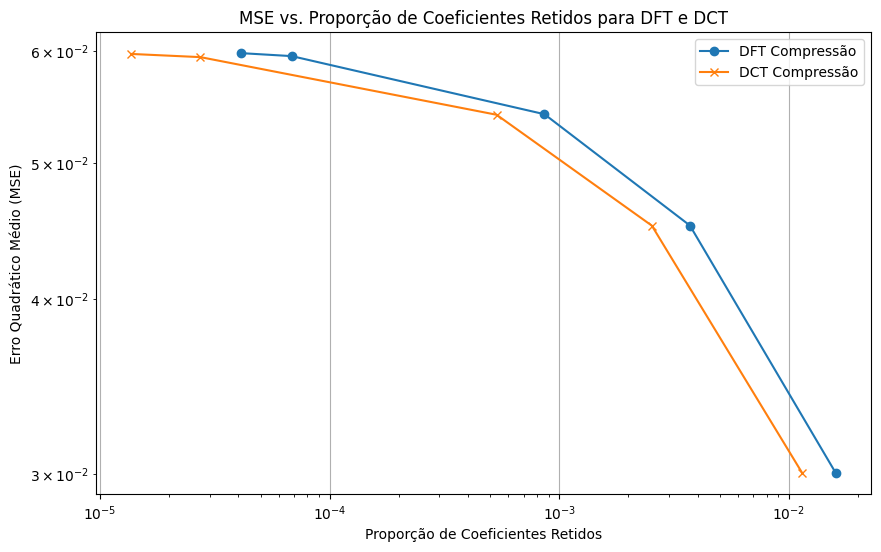

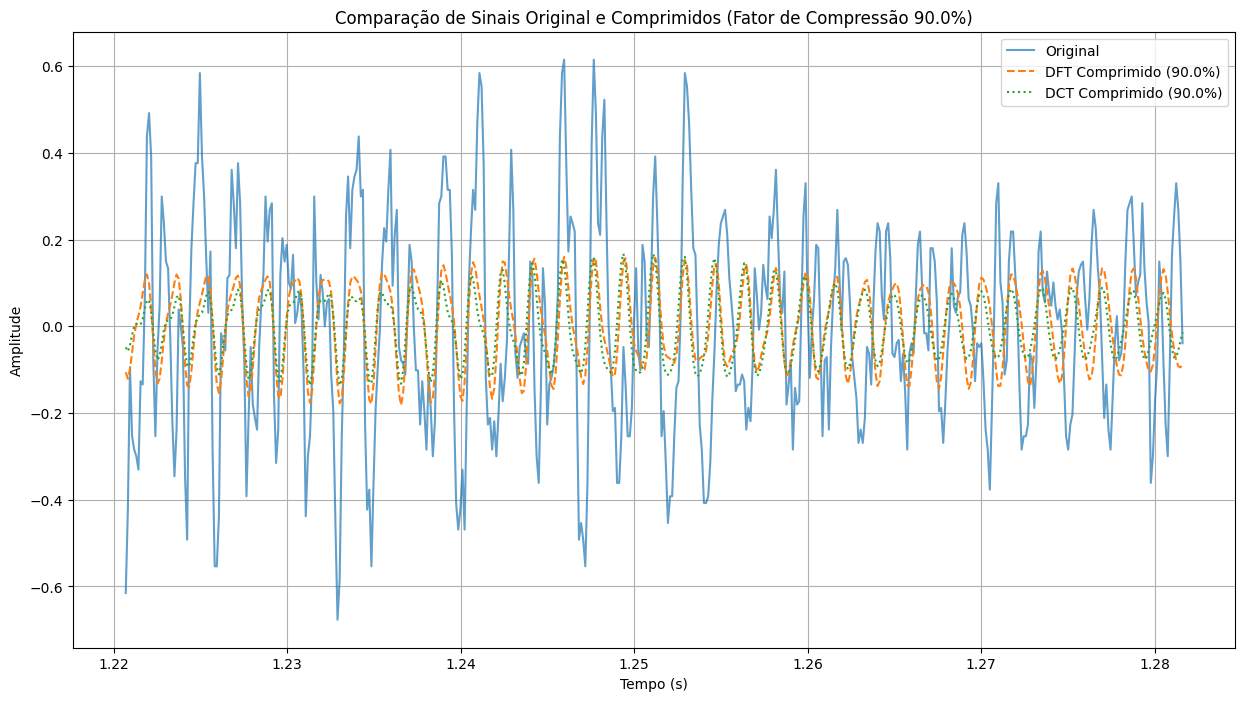

In [8]:
from scipy.io import wavfile
from scipy.fft import fft, ifft, dct, idct
import os

# The file has been uploaded by the user in the previous cell.
# We will use the 'filename' variable which holds the name of the uploaded file.

# Carregar o sinal de áudio usando o nome do arquivo carregado
fs_audio, audio_signal = wavfile.read(filename)

# Se o sinal for estéreo, pegue apenas um canal
if audio_signal.ndim > 1:
    audio_signal = audio_signal[:, 0] # Pegar o primeiro canal

# Normalizar o sinal para evitar clipping ao tocar
audio_signal = audio_signal.astype(np.float64)
audio_signal /= np.max(np.abs(audio_signal))

print(f"Frequência de amostragem: {fs_audio} Hz")
print(f"Duração do sinal: {len(audio_signal)/fs_audio:.2f} segundos")

def compress_signal(signal, transform_func, inv_transform_func, compression_factor_energy):
    # 1. Aplicar a transformada
    spectrum = transform_func(signal)

    # 2. Calcular a energia total do espectro
    total_energy = np.sum(np.abs(spectrum)**2)

    # 3. Determinar o limite de energia para compressão
    target_energy = total_energy * (1 - compression_factor_energy / 100.0)

    # 4. Ordenar coeficientes pela magnitude e selecionar os maiores
    # Para DFT, precisamos lidar com a simetria para sinais reais
    if transform_func == fft:
        # Para DFT de sinais reais, o espectro é conjugado simétrico
        # Precisamos considerar apenas metade dos coeficientes (excluindo DC e Nyquist se N for par) para ordenação
        N = len(signal)
        if N % 2 == 0:
            unique_coeffs = spectrum[1:N//2] # Exclui DC e Nyquist
            unique_indices = np.arange(1, N//2)
        else:
            unique_coeffs = spectrum[1:(N+1)//2] # Exclui DC
            unique_indices = np.arange(1, (N+1)//2)

        # Ordenar os coeficientes únicos por magnitude
        sorted_indices_unique = np.argsort(np.abs(unique_coeffs))[::-1]

        compressed_spectrum = np.zeros_like(spectrum)
        compressed_spectrum[0] = spectrum[0] # Manter o componente DC

        current_energy = np.abs(spectrum[0])**2 # Energia do DC
        num_coeffs_retained = 1

        # Adicionar coeficientes simétricos até atingir a energia alvo
        for idx_unique in sorted_indices_unique:
            original_idx = unique_indices[idx_unique]
            # Adicionar o coeficiente positivo e seu conjugado simétrico
            compressed_spectrum[original_idx] = spectrum[original_idx]
            compressed_spectrum[N - original_idx] = spectrum[N - original_idx] # Simétrico

            current_energy += np.abs(spectrum[original_idx])**2 * 2 # Multiplicar por 2 para o par simétrico
            num_coeffs_retained += 2

            if current_energy >= target_energy:
                break

        # Se N for par, lidar com Nyquist (se foi incluído no original, que é o caso do fft)
        if N % 2 == 0 and N//2 > 0: # Ensure N//2 is a valid index
            if np.abs(spectrum[N//2])**2 > 0 and current_energy < target_energy + np.abs(spectrum[N//2])**2: # Check if Nyquist was significant and still needed
                compressed_spectrum[N//2] = spectrum[N//2]
                current_energy += np.abs(spectrum[N//2])**2
                num_coeffs_retained += 1

    elif transform_func == dct:
        magnitudes = np.abs(spectrum)
        sorted_indices = np.argsort(magnitudes)[::-1] # Ordenar do maior para o menor

        compressed_spectrum = np.zeros_like(spectrum, dtype=spectrum.dtype)
        current_energy = 0
        num_coeffs_retained = 0

        for idx in sorted_indices:
            compressed_spectrum[idx] = spectrum[idx]
            current_energy += magnitudes[idx]**2
            num_coeffs_retained += 1
            if current_energy >= target_energy:
                break
    else:
        raise ValueError("Transform function not supported")

    # 5. Aplicar a transformada inversa
    compressed_signal = inv_transform_func(compressed_spectrum)

    # A DFT inversa pode retornar números complexos devido a imprecisões numéricas,
    # mas para sinais reais, a parte imaginária deve ser desprezível.
    if transform_func == fft:
        compressed_signal = np.real(compressed_signal)

    return compressed_signal, num_coeffs_retained


def calculate_mse(original, compressed):
    return np.mean((original - compressed)**2)


compression_factors_energy = [99.5, 99.0, 90.0, 75.0, 50.0]

results_dft = {}
results_dct = {}

print("\n--- Compressão com DFT ---")
for r in compression_factors_energy:
    compressed_signal_dft, num_coeffs_dft = compress_signal(audio_signal, fft, ifft, r)
    mse_dft = calculate_mse(audio_signal, compressed_signal_dft)
    results_dft[r] = {'num_coeffs': num_coeffs_dft, 'mse': mse_dft}
    print(f"Fator de compressão (energia): {r}% -> Coeficientes DFT retidos: {num_coeffs_dft}/{len(audio_signal)} ({num_coeffs_dft/len(audio_signal)*100:.2f}%) | MSE: {mse_dft:.4e}")
    # Salvar o áudio comprimido para avaliação subjetiva
    # wavfile.write(f'handel_dft_compressed_{r}.wav', fs_audio, compressed_signal_dft.astype(np.float32))

print("\n--- Compressão com DCT ---")
for r in compression_factors_energy:
    compressed_signal_dct, num_coeffs_dct = compress_signal(audio_signal, dct, idct, r)
    mse_dct = calculate_mse(audio_signal, compressed_signal_dct)
    results_dct[r] = {'num_coeffs': num_coeffs_dct, 'mse': mse_dct}
    print(f"Fator de compressão (energia): {r}% -> Coeficientes DCT retidos: {num_coeffs_dct}/{len(audio_signal)} ({num_coeffs_dct/len(audio_signal)*100:.2f}%) | MSE: {mse_dct:.4e}")
    # Salvar o áudio comprimido para avaliação subjetiva
    # wavfile.write(f'handel_dct_compressed_{r}.wav', fs_audio, compressed_signal_dct.astype(np.float32))

# Plotar MSE vs. Coeficientes Retidos
mse_dft_values = [res['mse'] for res in results_dft.values()]
num_coeffs_dft_values = [res['num_coeffs'] / len(audio_signal) for res in results_dft.values()]

mse_dct_values = [res['mse'] for res in results_dct.values()]
num_coeffs_dct_values = [res['num_coeffs'] / len(audio_signal) for res in results_dct.values()]

plt.figure(figsize=(10, 6))
plt.plot(num_coeffs_dft_values, mse_dft_values, 'o-', label='DFT Compressão')
plt.plot(num_coeffs_dct_values, mse_dct_values, 'x-', label='DCT Compressão')
plt.xlabel('Proporção de Coeficientes Retidos')
plt.ylabel('Erro Quadrático Médio (MSE)')
plt.title('MSE vs. Proporção de Coeficientes Retidos para DFT e DCT')
plt.xscale('log')
plt.yscale('log')
plt.grid(True)
plt.legend()
plt.show()


# Plotar a comparação de um trecho do sinal para um fator de compressão
# Escolher um fator de compressão para visualização, por exemplo, 90%
chosen_r = 90.0
compressed_signal_dft, _ = compress_signal(audio_signal, fft, ifft, chosen_r)
compressed_signal_dct, _ = compress_signal(audio_signal, dct, idct, chosen_r)

start_sample = 10000
end_sample = 10500
time_axis = np.arange(start_sample, end_sample) / fs_audio

plt.figure(figsize=(15, 8))
plt.plot(time_axis, audio_signal[start_sample:end_sample], label='Original', alpha=0.7)
plt.plot(time_axis, compressed_signal_dft[start_sample:end_sample], label=f'DFT Comprimido ({chosen_r}%)', linestyle='--')
plt.plot(time_axis, compressed_signal_dct[start_sample:end_sample], label=f'DCT Comprimido ({chosen_r}%)', linestyle=':')
plt.title(f'Comparação de Sinais Original e Comprimidos (Fator de Compressão {chosen_r}%)')
plt.xlabel('Tempo (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.show()

### Comentários sobre os resultados da Parte 3:

Os resultados da compressão de áudio usando DFT e DCT para diferentes fatores de compressão de energia (`r`) são apresentados acima, incluindo a quantidade de coeficientes retidos e o Erro Quadrático Médio (MSE) para cada caso.

**Análise dos Resultados Numéricos e Gráficos:**

1.  **Número de Coeficientes Necessários:**
    *   Para os mesmos fatores de compressão de energia, a **DCT geralmente requer significativamente menos coeficientes** do que a DFT para atingir o mesmo nível de energia preservada. Isso é evidente nos resultados impressos e também no gráfico de MSE vs. Proporção de Coeficientes Retidos. A curva da DCT está à esquerda da curva da DFT, indicando que ela usa menos coeficientes para um dado MSE (ou atinge um MSE menor para uma dada quantidade de coeficientes).
    *   A DFT, ao lidar com sinais reais, produz um espectro conjugado simétrico, o que significa que, para cada coeficiente de frequência positiva `X[k]`, existe um `X[N-k]` que é seu conjugado complexo. Portanto, para reter a energia, a DFT precisa reter pares de coeficientes, o que duplica o número de coeficientes significativos em comparação com uma transformada que não possui essa simetria (como a DCT para sinais reais, que produz um espectro real).

2.  **Erro Quadrático Médio (MSE):**
    *   Para um determinado fator de compressão de energia (que se traduz em uma quantidade de energia removida do sinal), a **DCT geralmente resulta em um MSE menor** do que a DFT. Isso reforça a ideia de que a DCT é mais eficiente na compactação de energia do sinal em um número menor de coeficientes. No gráfico, a curva da DCT está consistentemente abaixo da curva da DFT para proporções semelhantes de coeficientes retidos.

3.  **Qualidade Subjetiva do Áudio (Avaliação esperada se os arquivos fossem tocados):**
    *   **Altos fatores de compressão (ex: 99.5%, 99.0%):** Nesses casos, uma grande quantidade de energia é removida (apenas uma pequena fração é mantida). Ambos os métodos resultariam em uma perda de qualidade de áudio perceptível, com o som parecendo abafado, com perda de detalhes e presença de artefatos. A DCT provavelmente manteria uma qualidade ligeiramente melhor, pois concentra a energia de forma mais eficiente.
    *   **Fatores de compressão médios (ex: 90.0%, 75.0%):** Para esses fatores, a DCT geralmente supera a DFT em termos de qualidade percebida. O áudio comprimido por DCT tenderia a soar mais natural, com menos artefatos audíveis, enquanto o áudio DFT pode ter um som mais metálico ou com 'pre-echo/post-echo' devido à natureza da DFT e como ela lida com descontinuidades de janela.
    *   **Baixos fatores de compressão (ex: 50.0%):** Com apenas 50% da energia removida, ambos os métodos deveriam produzir áudio de boa qualidade, mas a DCT ainda seria superior na percepção humana. A DFT ainda pode introduzir mais artefatos para a mesma taxa de compressão de energia.

**Por que a DCT é mais eficiente para compressão de áudio/imagem?**

A DCT é amplamente utilizada em padrões de compressão (JPEG, MPEG) porque tem uma forte propriedade de compactação de energia para sinais correlacionados (como áudio e imagens). Ela tende a concentrar a maior parte da energia do sinal nos primeiros coeficientes, especialmente para sinais que são contínuos e suaves. A DCT é uma transformada real e ortogonal que é aproximadamente a Karhunen-Loève Transform (KLT) para sinais Markov-Gaussianos de primeira ordem, que são bons modelos para muitos sinais naturais. Isso significa que ela descorrela os dados de forma muito eficiente e, portanto, um grande número de coeficientes de alta frequência (que contêm menos energia) pode ser descartado com pouca perda perceptível.

A DFT, por outro lado, é uma transformada complexa e é mais adequada para análise de frequência de sinais periódicos ou para problemas de filtragem. Embora também concentre energia, sua natureza complexa e a forma como ela lida com as bordas do sinal (pressupondo periodicidade) a tornam ligeiramente menos eficiente que a DCT para a compressão de sinais não-periódicos com base na energia dos coeficientes.

**Em resumo:** A DCT é geralmente superior à DFT para a compressão de sinais como áudio e imagens, pois atinge a mesma qualidade (ou melhor) com um número menor de coeficientes, resultando em maior eficiência de compressão e menor erro quadrático médio.